# **A Rota do Neuromante**

**Autor**: Arthur Brandão do Nascimento

## **Introdução**

Este notebook tem por objetivo implementar e comparar dois algoritmos de aprendizado de máquina supervisionado de classificação. A partir de características sonoras, como centro de massa, frequências, amplitude, será previsto o tipo de arma utilizada no disparo.

Os algoritmos utilizados serão os de Floresta Aleatória e Multi Layer Perceptron (MLP). O desempenho da floresta aleatória será estimado por validação cruzada do tipo *k-fold* e do MLP por um dataset de validação, os hiperparâmetros dos modelos serão otimizados com o Optuna. Além disso, um modelo baseline será estabelecido para fins de comparação.

A métrica a ser otimizada será a f1-macro, que é adequada para problemas de classificação multiclasse, garantindo que todas as categorias (tipos de armas) tenham o mesmo peso na avaliação do desempenho, independentemente do número de amostras.

As características do dataset foram extraídas dos sinais de áudio originais utilizando técnicas de processamento de sinais, como: contraste espectral, centroíde espectral e mel-frequency cepstral coefficients.

In [1]:
import os

import librosa
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler, MinMaxScaler, StandardScaler

from optuna import create_study
from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend, JournalFileOpenLock

import torch
import torch.nn as nn
# import torch.optim as optim
import torchmetrics
from torch.utils.data import DataLoader, TensorDataset

import lightning as L
# import pytorch_lightning as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

## **Importando o Dataset**

O dataset foi obtido do [Kaggle](https://www.kaggle.com/datasets/emrahaydemr/gunshot-audio-dataset/data) [1, 16]. Após o download, o arquivo ``.zip`` foi extraído e renomeado de ``archive`` para ``guns_dataset``. Para que fosse possível localizar o caminho de todos os arquivos de áudio e suas respectivas armas, e salvar essas informações em um arquivo ``.csv``, utilizou-se o código da célula abaixo:

**``OBS:``** Na página de discussões do dataset foi apontado que as armas M4 e M16 são basicamente a mesma arma e podem ser utilizados como a mesma arma, de forma que o espectro de som de ambas é o mesmo. Então, para evitar problemas com o vazamento de dados a pasta ``./guns_dataset/M16`` foi excluída.

In [2]:
dataset_path = "./guns_dataset"
final_data = {"gun_type": [], "sound_file_path": []}

for gun_name in os.listdir(dataset_path):
    gun_dir = os.path.join(dataset_path, gun_name)
    
    if os.path.isdir(gun_dir):
        for file_name in os.listdir(gun_dir):
            file_path = os.path.join(gun_dir, file_name)
            
            final_data["gun_type"].append(gun_name)   
            final_data["sound_file_path"].append(file_path) 

df = pd.DataFrame(final_data)
df.to_csv("gun_models_and_path.csv", index=False, encoding="utf-8")
display(df.head(10))

,gun_type,sound_file_path
0,AK-12,./guns_dataset\AK-12\3 (1).wav
1,AK-12,./guns_dataset\AK-12\3 (10).wav
2,AK-12,./guns_dataset\AK-12\3 (11).wav
3,AK-12,./guns_dataset\AK-12\3 (12).wav
4,AK-12,./guns_dataset\AK-12\3 (13).wav
5,AK-12,./guns_dataset\AK-12\3 (14).wav
6,AK-12,./guns_dataset\AK-12\3 (15).wav
7,AK-12,./guns_dataset\AK-12\3 (16).wav
8,AK-12,./guns_dataset\AK-12\3 (17).wav
9,AK-12,./guns_dataset\AK-12\3 (18).wav


O dataset gerado possui duas colunas: uma com o tipo de arma (``gun_type``) e outra com o caminho para o arquivo ``.wav`` (``sound_file_path``). No total, há 751 arquivos, destes, as armas AK-47 e Zastava M92 apresentam uma quantidade menor de amostras, 72 e 82, respectivamente, enquanto as demais contam com aproximadamente 100 amostras cada.

In [3]:
df_paths = pd.read_csv("gun_models_and_path.csv")

display(df_paths.head())
display(f"Formato: {df_paths.shape}")

print(f"Contagem dos tipos de arma:\n{df_paths["gun_type"].value_counts()}")

,gun_type,sound_file_path
0,AK-12,./guns_dataset\AK-12\3 (1).wav
1,AK-12,./guns_dataset\AK-12\3 (10).wav
2,AK-12,./guns_dataset\AK-12\3 (11).wav
3,AK-12,./guns_dataset\AK-12\3 (12).wav
4,AK-12,./guns_dataset\AK-12\3 (13).wav


'Formato: (751, 2)'

Contagem dos tipos de arma:
gun_type
IMI Desert Eagle    100
MP5                 100
MG-42               100
M4                  100
M249                 99
AK-12                98
Zastava M92          82
AK-47                72
Name: count, dtype: int64


## **Extração de características dos áudios**

**OBS:** Para o desvio padrão de cada uma das características foi utilizado o ``ddof=1``, para aplicar a correção de Bessel, visto que o dataset utiliza uma amostragem do áudio original.

As docstrings das funções desse documento foram geradas pelo gemini: [conversa](https://gemini.google.com/share/4e48a434f7a0), visto que considero esse processo excessivamente mecânico.

#### **MFCCs (Mel-Frequency Cepstral Coefficients)**

Os MFCCs representam a percepção humana do som de forma linear até cerca de 1 kHz e logarítmica acima disso. Para obtê-los [2], o áudio é primeiramente dividido em janelas. Em seguida, o sinal é convertido do domínio do tempo para o domínio da frequência por meio da Transformada de Fourier. As frequências resultantes são mapeadas para escala mel [3], e aplica-se um logarítmo em cada banda mel. Ao fim, uma Transformada de Cosseno Discreta (DCT) é aplicada para comprimir a informação e gerar os coeficientes finais.

Nesse trabalho, optou-se por utilizar ``n_mfcc = 13`` coeficientes, ou seja, cada janela é representada por 13 coeficientes. Os primeiros coeficientes capturam as caracterísicas mais gerais e relevantes do som, enquanto, a partir do décimo terceiro, o ruído já começa a ter presença significativa.

Ao final do processo, foi feita a média e desvio padrão de cada um dos coeficientes.



In [4]:
def extract_mfcc(y_wave, sr_wave, n_mfcc_wave):
    """
    Extrai os coeficientes MFCC (Mel-Frequency Cepstral Coefficients) do sinal de áudio e calcula suas médias e desvios padrões.

    Parâmetros:
    - y_wave: array contendo o sinal de áudio no domínio do tempo
    - sr_wave: taxa de amostragem (sample rate) do sinal de áudio
    - n_mfcc_wave: número de coeficientes MFCC a serem gerados

    Retorna:
    - media_mfccs: array com a média de cada coeficiente MFCC
    - std_mfccs: array com o desvio padrão de cada coeficiente MFCC (com correção de Bessel)
    """

    mfccs = librosa.feature.mfcc(y=y_wave, sr=sr_wave, n_mfcc=n_mfcc_wave)
    media_mfccs = np.mean(mfccs, axis=1)
    std_mfccs = np.std(mfccs, axis=1, ddof=1)

    return media_mfccs, std_mfccs

#### **Espectrograma Mel**

O espectro mel representa o conteúdo de frequência de um áudio mapeado para a escala mel, que se aproxima da percepção auditiva humana. O processo para obtê-lo [2] é semelhante ao utilizado para os MFCCs: o áudio é divido em janelas e o sinal é convertido do domínio do tempo para o domínio da frequência por meio da Transformada de Fourier. Em seguida, as frequências resultantes são mapeadas para uma escala mel [3], e aplica-se um logarítimo em cada banda mel - por padrão são geradas 128 bandas. Ao final, tem-se o valor de cada banda mel é o número de frames que cobrem cada banda (``[shape=(..., n_mels, t)]``). 

Em seguida, foi calculada a média e o desvio padrão dos valores mel, cujos significados são:

- **Média**: indica o quão preenchido está o espectro e o seu volume geral.

- **Desvio padrão**: reflete a estabilidade do som, se há muitos picos e silêncios ou se o som é mais constante.

In [5]:
def extract_mel_spectrogram(y_wave, sr_wave):
    """
    Gera o espectrograma Mel do áudio e calcula a média e desvio padrão para cada banda Mel.

    Parâmetros:
    - y_wave: array contendo o sinal de áudio no domínio do tempo
    - sr_wave: taxa de amostragem do sinal de áudio

    Retorna:
    - media_mel: array com as médias das bandas do espectrograma Mel
    - std_mel: array com os desvios padrões das bandas do espectrograma Mel
    """
    
    mel_spectrogram = librosa.feature.melspectrogram(y=y_wave, sr=sr_wave)
    media_mel = np.mean(mel_spectrogram, axis=1)
    std_mel = np.std(mel_spectrogram, axis=1, ddof=1)

    return media_mel, std_mel


#### **Centróide Espectral**

O centroíde espectral representa o centro de massa do espectro das frequências [4], indicando em qual frequência, em média, a energia do som está concentrada. Para obtê-lo [4]: o áudio é dividido em janelas e convertido do domínio do tempo para o domínio da frequência usando a transformada de Fourier, calculando-se também a magnitude para cada uma das frequências. Em seguida, calcula-se a média ponderada das frequências presentes no sinal, utilizando suas magnitudes como pesos.

Em termos gerais, o centroíde espetral indica se o som é mais grave ou mais agudo. Quanto maior o seu valor, mais agudo e brilhante é o som; quanto menor, mais grave e encorpado ele se apresenta.

Assim como nas demais caracterísitcas, aqui também foi feita a média e desvio padrão dos centróides espectrais de cada uma das janelas.


In [6]:
def extract_spectral_centroid(y_wave, sr_wave):
    """
    Calcula o centróide espectral do áudio, além de suas médias e desvios padrões.

    Parâmetros:
    - y_wave: array contendo o sinal de áudio no domínio do tempo
    - sr_wave: taxa de amostragem do sinal de áudio

    Retorna:
    - media_spectral_centroid: array com a média do centróide espectral
    - std_spectral_centroid: array com o desvio padrão do centróide espectral
    """

    spectral_centroid = librosa.feature.spectral_centroid(y=y_wave, sr=sr_wave)
    media_spectral_centroid = np.mean(spectral_centroid, axis=1)
    std_spectral_centroid = np.std(spectral_centroid, axis=1, ddof=1)

    return media_spectral_centroid, std_spectral_centroid


#### **Contraste espectral**

O contraste espectral quantifica a diferença entre as partes mais fortes e mais fracas do espectro de frequências em determinadas regiões [5]. Para obtê-lo, o áudio primeiramente é convertido do domínio do tempo para o domínio da frequência pela Transformada de Fourier. Em seguida, é dividido, por padrão, em 6 bandas. Em cada uma delas identificam-se as frequências com maior energia, picos; e as frequências com menor energia, vales. Nesse processo, são utilizados percentis: os picos correspondem, por padrão, ao maior valor desconsiderando-se os 2% (``quantile=0.02``) das frequências com menor energia; e os vales correspondem ao menor valor também ignorando-se os 2% das frequências com menor energia.

Um contraste alto indica um som rítmico ou harmônico, visto que há uma estrutura clara de picos e vales bem definidos. Por outro lado, um contraste baixo significa que a energia está distribuída de forma mais uniforme ao longo do espectro, sem picos muito destacados ou vales profundos, o que caracteriza um som mais ruidoso ou contínuo.

Ao final foi feita a média e desvio padrão dos contrastes espectrais em cada banda.


In [7]:
def extract_spectral_contrast(y_wave, sr_wave):
    """
    Extrai o contraste espectral do sinal de áudio, quantificando a diferença entre as partes mais fortes e mais fracas do espectro de frequências.

    Parâmetros:
    - y_wave: array contendo o sinal de áudio no domínio do tempo
    - sr_wave: taxa de amostragem do sinal de áudio

    Retorna:
    - media_contrast: array com a média dos contrastes espectrais por banda
    - std_contrast: array com o desvio padrão dos contrastes espectrais por banda
    """

    spectral_contrast = librosa.feature.spectral_contrast(y=y_wave, sr=sr_wave)
    media_contrast = np.mean(spectral_contrast, axis=1)
    std_contrast = np.std(spectral_contrast, axis=1, ddof=1)

    return media_contrast, std_contrast

#### **Zero-Crossing Rate (ZCR)**

O Zero-Crossing Rate (ZCR) representa a taxa com que um sinal de áudio cruza o eixo horizontal, ou seja, muda de positivo para negativo (ou vice-versa) ao longo do tempo [6]. Para obtê-lo, o áudio é divido em janelas, e o algorítimo conta quantas vezes o sinal muda de sinal, se uma amostra é positiva e a próxima é negativa (ou o contrário) isso contado como um cruzamento. Em seguida, a taxa é calculada dividindo-se o número de cruzamentos pelo total de amostras da janela.

Um ZCR baixo indica que um som está variando lentamente, o que é comum em sons graves. Por outro lado, um ZCR alto indica que o sinal está variando rapidamente, característica comum em sons agudos.

In [8]:
def extract_zcr(y_wave):
    """
    Calcula a taxa de cruzamento por zero (Zero-Crossing Rate - ZCR) de um sinal de áudio.

    Parâmetros:
    - y_wave: array contendo o sinal de áudio no domínio do tempo

    Retorna:
    - media_zcr: array com a média da taxa de cruzamento por zero
    - std_zcr: array com o desvio padrão da taxa de cruzamento por zero
    """

    zcr = librosa.feature.zero_crossing_rate(y=y_wave)
    media_zcr = np.mean(zcr, axis=1)
    std_zcr = np.std(zcr, axis=1, ddof=1)

    return media_zcr, std_zcr

#### **Chroma Features**

O Chroma representa a intensidade de cada uma das 12 notas musicais presentes em um som, independentemente da oitava [7]. Para obtê-lo, o áudio é dividido em janelas e o sinal é convertido do domínio do tempo para o domínio das frequências por meio Transformada de Fourier de Curto Prazo (STFT). Em seguida, cada frequência é convertida para a nota musical mais próxima. Todas as frequências de um mesmo frame que correspondem à mesma classe de nota são somadas, e esse valor é normalizado, obtendo-se, assim, um vetor de 12 valores de intensidade, um para cada nota.

Por fim, foi feita a média e desvio padrão dos valores de intensidade para cada nota entre as janelas, o que permite observar a predominância de cada nota nos áudios analisados.

No caso de classificação de disparos de arma, que são sons pouco periódicos e sem estrutura harmônica definida, o Chroma provavelmente não será útil. Ainda assim, foi utlizado como uma forma observar seu funcionamento.

In [9]:
def extract_chroma(y_wave, sr_wave):
    """
    Extrai as características de Chroma, que representam a intensidade das notas musicais de um áudio, calculando suas médias e desvios.

    Parâmetros:
    - y_wave: array contendo o sinal de áudio no domínio do tempo
    - sr_wave: taxa de amostragem do sinal de áudio

    Retorna:
    - media_chroma: array com as médias de intensidade associadas a cada nota
    - std_chroma: array com os desvios padrões de intensidade de cada nota
    """
    
    chroma_stft = librosa.feature.chroma_stft(y=y_wave, sr=sr_wave)
    media_chroma = np.mean(chroma_stft, axis=1)
    std_chroma = np.std(chroma_stft, axis=1, ddof=1)

    return media_chroma, std_chroma

#### **Juntando as funções**

Para extrair cada uma das features listadas anteriormente para cada áudio, foi criada a ``função extract_features()``. Além de retornar um vetor 1D com as features extraídas, a função também pode retornar os nomes das colunas correspondentes (``return_nomes_colunas=True``), os quais são utilizados na criação do dataset com as features extraídas.

In [10]:
def extract_features(file_path, return_nomes_colunas=False):
    """
    Função agregadora que extrai e concatena métricas de MFCC, Mel, Centróide Espectral, Contraste, ZCR e Chroma de um arquivo de áudio.

    Parâmetros:
    - file_path: caminho em texto (string) para o arquivo de áudio
    - return_nomes_colunas: flag booleana indicando se a função deve retornar também os nomes das colunas de features

    Retorna:
    - feature_1d: array 1D horizontal contendo as características empilhadas e extraídas
    - nomes_colunas (opcional): lista contendo as strings com os nomes das características
    """

    y_wave, sr_wave = librosa.load(file_path)

    results_features = {
        "mfcc": extract_mfcc(y_wave, sr_wave, n_mfcc_wave=13),
        "mel": extract_mel_spectrogram(y_wave, sr_wave),
        "spectral_centroid": extract_spectral_centroid(y_wave, sr_wave),
        "contrast": extract_spectral_contrast(y_wave, sr_wave),
        "zcr": extract_zcr(y_wave),
        "chroma": extract_chroma(y_wave, sr_wave)
    }

    feature_arrays = []
    nomes_colunas = []

    for nome_feature, (media, std) in results_features.items():
        
        feature_arrays.extend([media, std])

        if return_nomes_colunas:    
            nomes_colunas.extend([f"{nome_feature}_media_{i+1}" for i in range(len(media))])
            nomes_colunas.extend([f"{nome_feature}_std_{i+1}" for i in range(len(std))])

    feature_1d = np.hstack(feature_arrays)

    if return_nomes_colunas:
        return feature_1d, nomes_colunas
    
    return feature_1d


#### **Constrindo um dataset com as features extraídas**

A função abaixo itera pelos caminhos dos arquivos de áudio, extrai as features de cada um deles e retorna um dataset com as informações extraídas.

In [11]:
def make_feature_dataframe(df_paths):
    """
    Itera sobre os caminhos e extrai as características acústicas listadas no notebook, formando um DataFrame pronto para uso no treinamento.

    Parâmetros:
    - df_paths: DataFrame inicial com colunas descrevendo o caminho e o tipo de arma (target)

    Retorna:
    - df: DataFrame final estruturado contendo as matrizes de features e seus respectivos "gun_type"
    """

    dataset_linhas = []   
    nomes_colunas = None

    for idx, linha in df_paths.iterrows():
        file_path = linha["sound_file_path"]
        gun_type = linha["gun_type"]

        if nomes_colunas is None:
            features_1d, nomes_colunas = extract_features(file_path, return_nomes_colunas=True)
        else:
            features_1d = extract_features(file_path)

        dataset_linhas.append([gun_type] + features_1d.tolist())

    df = pd.DataFrame(dataset_linhas, columns=["gun_type"] + nomes_colunas)

    return df

In [12]:
df = make_feature_dataframe(df_paths)

display(df.head(10))
print(f"Formato: {df.shape}")


C:\Users\arthur25004\AppData\Roaming\Python\Python312\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


,gun_type,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,mfcc_media_7,mfcc_media_8,mfcc_media_9,...,chroma_std_3,chroma_std_4,chroma_std_5,chroma_std_6,chroma_std_7,chroma_std_8,chroma_std_9,chroma_std_10,chroma_std_11,chroma_std_12
0,AK-12,-171.605377,71.285637,-19.825487,-2.162487,-4.999956,-5.551470,-7.822193,-0.215192,-8.519834,...,0.192955,0.186204,0.193684,0.223359,0.188662,0.202284,0.178258,0.238582,0.217830,0.226442
1,AK-12,-16.390745,63.723286,-12.611650,-2.966142,-13.709801,-6.064076,-15.475484,-6.503496,-13.198974,...,0.157676,0.226367,0.258935,0.248305,0.226618,0.189304,0.199845,0.247110,0.170327,0.209289
2,AK-12,-304.865936,98.038864,-24.063431,-5.935536,-6.952144,-4.035964,-8.046197,1.046978,-2.406871,...,0.178085,0.224397,0.210617,0.213502,0.205259,0.201332,0.215134,0.226494,0.210354,0.213794
3,AK-12,-127.034081,68.531387,-9.903762,-5.387527,-11.311323,-5.520391,-11.247422,-5.463551,-9.946875,...,0.213469,0.211649,0.240995,0.273009,0.221448,0.238928,0.258833,0.218491,0.203545,0.190965
4,AK-12,-72.022278,81.035484,-15.902526,-2.386111,-15.858383,-6.126534,-16.380098,-5.141746,-12.423942,...,0.187643,0.200397,0.234231,0.283729,0.235032,0.216666,0.203085,0.231954,0.172854,0.202326
5,AK-12,-2.040761,67.646820,-7.095361,-3.216621,-14.769461,-7.100462,-15.647412,-5.329108,-13.361465,...,0.169189,0.173173,0.173121,0.233742,0.260848,0.199192,0.216006,0.178081,0.212486,0.191865
6,AK-12,5.808968,60.997105,-7.513953,-3.345636,-12.541905,-8.746907,-15.008804,-4.866399,-12.753549,...,0.173266,0.186459,0.196804,0.252638,0.238410,0.206119,0.211901,0.192530,0.231102,0.174261
7,AK-12,-2.425685,65.623970,-7.082948,-4.317845,-12.259196,-8.855823,-15.023139,-4.435404,-13.204572,...,0.178764,0.217812,0.192164,0.251904,0.236248,0.206201,0.215425,0.173089,0.194501,0.156895
8,AK-12,-87.186859,78.825172,-14.867887,-5.212098,-13.021231,-8.263900,-14.800679,-2.792002,-12.133399,...,0.195578,0.231087,0.234881,0.249100,0.212415,0.212100,0.170952,0.202918,0.183821,0.215852
9,AK-12,-181.697937,67.015144,-6.889086,-1.855904,-1.956999,5.016802,-5.895965,-2.260715,-9.544379,...,0.207714,0.198582,0.219760,0.234777,0.237865,0.220207,0.253176,0.253905,0.207856,0.209518


Formato: (751, 325)


## **Separando os dados**

### **Definindo as ``FEATURES`` e o ``TARGET``**




Variável alvo (**``TARGET``**):

- ``"gun_type"`` - o tipo de arma que produziu o som: IMI Desert Eagle, MP5, MG-42, M4, M249, AK-12, Zastava M92 e AK-47 

Features (**``FEATURES``**):

-  ``"mfcc_metrica_n"``, ``"mel_metrica_n"``, ``"spectral_centroid_metrica_n"``, ``"contrast_metrica_n"``, ``"zcr_metrica_n"``, ``"chroma_metrica_n"`` - características extraídas dos arquivos de áudio, onde "metrica" pode ser "media" ou "std" e "n" é o número da métrica (por exemplo, para MFCCs, n pode variar de 1 a 13). 

In [13]:
FEATURES = [col for col in df.columns if col != "gun_type"]

TARGET = ["gun_type"]

### **Separando os dados de treino, validação e teste**

Com as features e os targets definidos, podemos separar os dados em três conjuntos: treino, validação e teste. Os dados de validação servem para estimar o desempenho do modelo, sem que os dados de teste sejam utilizados nesse processo, evitando o vazamento de dados.

In [14]:
TAMANHO_TESTE = 0.1
TAMANHO_VALIDACAO = 0.1

SEED = 404

df_treino_val, df_teste = train_test_split(df, test_size=TAMANHO_TESTE, random_state=SEED)

df_treino, df_val = train_test_split(df_treino_val, test_size=TAMANHO_VALIDACAO, random_state=SEED)

X_teste = df_teste.reindex(FEATURES, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

X_treino = df_treino.reindex(FEATURES, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_val = df_val.reindex(FEATURES, axis=1).values
y_val = df_val.reindex(TARGET, axis=1).values.ravel()

## **Codificação do target**

Como o algorítimo de Multi Layer Perceptron (MLP), detalhado mais adiante, não processa diretamente as classes em texto é necessário convertê-las para números. Para isso, foi utilizado o ``LabelEncoder()`` do sklearn. 

In [15]:
label_encoder = LabelEncoder()
label_encoder.fit(y_treino)

y_treino_norm = label_encoder.transform(y_treino)
y_val_norm = label_encoder.transform(y_val)
y_teste_norm = label_encoder.transform(y_teste)

classes_label_encoder = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Classes e seus respectivos valores: {classes_label_encoder}")

Classes e seus respectivos valores: {'AK-12': np.int64(0), 'AK-47': np.int64(1), 'IMI Desert Eagle': np.int64(2), 'M249': np.int64(3), 'M4': np.int64(4), 'MG-42': np.int64(5), 'MP5': np.int64(6), 'Zastava M92': np.int64(7)}


## **Criando os modelos e espaços de busca**

Serão criados os seguintes modelos para comparação:

- Baseline (DummyClassifier)
- Multi Layer Perceptron (MLP)
- Floresta Aleatória (RF)

Para a otimização dos hiperparâmetros dos modelos RF e MLP será utilizado o optuna, um framework de otimização de hiperparâmetros. Que automatiza o processo de econtrar o conjunto ótimo de hiperparâmetros para um dado modelo, almejando minimizar ou maximizar uma função específica.

No Optuna, os ``Trials`` são as tentativas com diferentes combinações de hiperparâmetros e o ``Study`` é o conjunto de trials para um determinado objetivo.

Nesse contexto, a função ``cria_instancia_modelo`` serve para criar uma instância do modelo escolhido, recebendo um trial.
Para definir o espaço do dicionário dos parâmetros é usado o ``trial.suggest_*()``.

### **Baseline**

O baseline estabelece uma referência mínima de desempenho, onde qualquer modelo útil deve superar essa referência.

No caso, foi utilizado o ``DummyClassifier(strategy='most_frequent')``, que prevê sempre a moda dos valores de y. 

In [16]:
modelo_baseline = DummyClassifier(strategy="most_frequent")

modelo_baseline.fit(X_treino, y_treino_norm)
y_prev_estimativa_baseline = modelo_baseline.predict(X_val)

f1_macro_estimativa_dummy = f1_score(y_val_norm, y_prev_estimativa_baseline, average="macro")
print(f"Estimativa f1-macro baseline: {f1_macro_estimativa_dummy}")

Estimativa f1-macro baseline: 0.007142857142857143


### **Instância MLP** [13] 

Um Multilayer Perceptron (MLP) é uma rede neural que possui três ou mais camadas (uma **entrada** e uma **saída**, com uma ou mais **camadas ocultas**) e em cada camada há um determinado número de **neurônios artificiais** [8]. Cada neurônio de uma camada está conectado a todos os neurônios da camada seguinte por um certo peso $w_{ij}$. Além disso, cada conexão passa por uma função de ativação, que introduz uma não linearidade ao modelo, permitindo que ele aprenda padrões complexos.

O aprendizado da MLP ocorre em 5 etapas que se repetem a cada época de treinamento:

1. **Forward Pass**: os dados de entrada são passados pela rede, camada por camada, até chegar à camada de saída, onde é gerada a previsão.

2. **Cálculo de Perda**: o erro entre a previsão e o valor real é calculado usando uma função de perda.

3. **Zerar os Gradientes**: os gradientes dos pesos são zerados para evitar que se acumulem ao longo das épocas.

4. **Backpropagation**: o erro é propagado de trás para frente através da rede, calculando os gradientes dos pesos.

5. **Atualização dos Pesos**: os pesos da rede são atualizados usando um algoritmo de otimização, como o gradiente descendente, levando em consideração a taxa de aprendizado.

Conceitos importantes: 

- **Camadas (entrada, saída e ocultas)**
    - **entrada**: recebe como entrada um exemplo do conjunto de dados.

    - **ocultas**: são as camadas entre a entrada e a saída. A segunda camada recebe como entrada o vetor de saída da primeira camada. As camadas seguintes funcionam de forma semelhante: cada camada recebe como entrar a o vetor de saída da camada anterior.

    - **saída**: é a última camada, que retorna a previsão final.

- **Função de ativação**: é uma função matemática, tal que a saída é dada por $f(\sum _i{w_i x_i + b})$.

- **Épocas**: é o número de vezes que o processo de aprendizado (forward pass, cálculo de perda, backpropagation e atualização dos pesos) é repetido para todo o conjunto de dados.

- **Neurônios artificiais**: são as unidades básicas de processamento em uma rede neural, inspirados nos neurônios biológicos. Cada neurônio recebe múltiplas entradas, aplica uma função de ativação e produz uma saída que é passada para os neurônios da camada seguinte.

#### **Definindo o ``DataModule``**

Primeiramente, para criar uma rede usando o ``Lightning`` utiliza-se o objeto ``L.LightningDataModule``, que pode ser utilizados para representar todo o processo de preparação dos dados, desde a coleta, split e tratamento em um único local. Por questões de tornar o notebook mais didático, podendo-se visualizar cada etapa, optou-se por fazer o tratamento de dados separadamente.

Duas configurações importantes do ``DataModule`` são: 

- **``tamanho_lote``**: representa o número de exemplos que serão utilizado para treinar o modelo ao mesmo tempo. De forma que se tivermos um conjunto de dados com 1000 exemplos e um tamanho de lote de 100, o modelo será atualizado 10 vezes por época, ou seja, a cada 100 exemplos. Se o tamanho do lote for muito pequeno, o modelo pode demorar mais para convergir, visto que os pesos são atualizados com mais frequência, o que pode também levar a um aprendizado mais ruídoso.

- **``num_trabalhadores``**: representa quantos núcleos de processamento (CPU) você deseja utilizar para as operações relacionadas aos dados. É importante não escolher um valor muito pequeno, para que não haja um garagalo no treinamento, mas também não é recomendado escolher um valor muito alto, para evitar sobrecarregar o sistema e afetar outras tarefas.

In [17]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        dataset_treino,
        dataset_val,
        dataset_teste,
        tamanho_lote=32,
        num_trabalhadores=2,
    ):
        super().__init__()

        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores
        self.dataset_treino = dataset_treino
        self.dataset_val = dataset_val
        self.dataset_teste = dataset_teste

    def train_dataloader(self):
        return DataLoader(
            self.dataset_treino,
            batch_size=self.tamanho_lote,
            num_workers=self.num_trabalhadores,
            persistent_workers=True,
            shuffle=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.dataset_val,
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            persistent_workers=True,
            shuffle=False,
        )

    def test_dataloader(self):
        return DataLoader(
            self.dataset_teste,
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            persistent_workers=True,
            shuffle=False,
        )

### **Definindo a arquitetura da MLP** [14]

Para criar uma rede neural no ``Lightning``, é necessário criar uma classe que herda de ``L.LightningModule``, bem como definir o número de camadas e neurônios (topografia da rede), as funções de ativação, o otimizador, a função de perda e também como proceder durante as etapas de treinamento, validação e teste.
 
- **Taxa de Aprendizado:** - Controla a taxa com que os pesos da rede são atualizados durante o treinamento, se haverá uma grande ou pequena alteração. Se a taxa de aprendizado for muito alta, o modelo pode divergir e pular o mínimo global, enquanto uma taxa muito baixa pode resultar em um processo de treinamento muito demorado e possivelmente ficar preso em mínimos locais.

- **Camadas Ocultas e Neurônios:** A arquitetura permite a escolha flexível do número de camadas ocultas, bem como da quantidade de neurônios em cada uma delas. 
Isso permite que o optuna encontre parâmetros ideais para o modelo.

- **Ativação na Camada de Saída:** Existe a possibilidade de escolhermos se haverá ou não a aplicação de uma função de ativação na última camada. A presença dessa função ao final geralmente depende da implementação da função de perda escolhida, pois algumas já calculam as probabilidades internamente a partir das saídas brutas (*logits*) da rede.

- **Otimizador (``Adam``):** Para atualizar os pesos da rede e minimizar o erro durante o treinamento, foi utilizado o otimizador **Adam** (*Adaptive Moment Estimation*). Esse otimizador ajusta individualmente as taxas de aprendizado para cada parâmetro, em que a quantidade ajustada é influenciada por ambos o primeiro momento (capturando a quantidade de movimento dos gradientes) e o segundo momento (refletindo a variabilidade dos gradientes). Isso permite que o Adam se adapte dinamicamente ao longo do treinamento, com uma taxa de aprendizado adaptativa, baseada no quão frequente um parâmetro é atualizado [10]. 
O funcionamento do algorítimo foi mais detalhadomente explicado na seção de apêndice.  

- **Função de Perda (``CrossEntropyLoss``):** A função de perda é a métrica matemática que o otimizador tenta minimizar. Como se trata de um problema de classificação com múltiplas categorias, foi utilizada a ``CrossEntropyLoss`` [11, 12]. A ideia por trás dessa função é quantificar o quão bem as previsões de um modelo correspondem aos resultados reais, de forma que uma grande confiança em previsões incorretas tenha uma grande penalidade. Por usar a função logarítmica, a perda de entropia cruzada é mais sensível a mudanças para previsões de baixa confiança na classe correta. A função da entropia cruzada pode ser expressa como: $$L = -\sum_{k=1}^{K} y_k \log(p_k)$$ onde $y_k$ é a probabilidade da classe $k$ (1 para a classe correta e 0 para as demais) e $p_k$ é a probabilidade prevista para a classe $k$.

    A previsão geralmente vem na forma de *logits*, que são os valores brutos de saída da rede que não possuem uma interpretação probabilística direta. Para converter esses valores em probabilidades, é aplicada a função ``softmax``, que garante que as saídas somem 1. Essa função é representado por: $$p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$ onde $z_k$ é o logit para a classe $k$ e $p_k$ é a probabilidade prevista para a classe $k$.

- **Métrica de Avaliação (``F1-Macro``):** O desempenho do treinamento e validação é avaliado através da métrica **F1-Macro**. No caso de classificação com múltiplas classes, ele calcula a média harmônica entre precisão e *recall* de cada classe de forma independente e ao final faz a média dos valores f1. Será dado o mesmo peso para todas as classes, independentemente se temos mais amostras de áudio para um determinado tipo de arma do que para outro.

Embora o Optuna tenha como objetivo maximizar a métrica de avaliação, que é o ``f1-macro``, no treino de cada instância da MLP o modelo busca minimizar a função de perda que é a ``CrossEntropyLoss``.

In [18]:
class MLP(L.LightningModule):
    def __init__(
            self, 
            num_dados_entrada, 
            camadas_ocultas,
            funcao_ativacao,
            num_targets, 
            learning_rate=1e-3,
            funcao_ativacao_na_saida=False
    ):
        super().__init__()

        self.save_hyperparameters() 
        self.learning_rate = learning_rate

        arquitetura = []

        # primeira camada oculta
        arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
        arquitetura.append(funcao_ativacao)

        # demais camadas ocultas
        for i in range(1, len(camadas_ocultas)):
            arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
            arquitetura.append(funcao_ativacao)

        # camada de saída
        arquitetura.append(nn.Linear(camadas_ocultas[-1], num_targets))

        if funcao_ativacao_na_saida:
            arquitetura.append(funcao_ativacao)

        self.camadas = nn.Sequential(*arquitetura)
    
        self.fun_perda = nn.CrossEntropyLoss()

        self.f1_macro = torchmetrics.F1Score(
            task="multiclass",
            num_classes=num_targets,
            average="macro"
        )

    def forward(self, x):
        return self.camadas(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)             
        loss = self.fun_perda(y_pred, y) 
        self.log("loss", loss, prog_bar=True, on_step=False, on_epoch=True) 
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)
        
        f1 = self.f1_macro(y_pred, y)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_f1_macro', f1, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)
        f1 = self.f1_macro(y_pred, y)
        
        self.log("test_loss", loss)
        self.log("test_f1_macro", f1)


#### **Agora sim criando a instância do modelo**


Hiperparâmetros otimizados:

- **``lr``**: é a taxa de aprendizado (*learning rate*) do modelo. $1 \cdot 10^{-5} < lr < 1 \cdot 10^{-2}$, *``log=True``*

- **``num_camadas``**: é número de camadas ocultas da MLP. $1 \leq num\_camadas \leq 3$

- **``tamanho_camada_{i}``**: representa o número de neurônios na camada oculta $i$. $16 \leq tamanho\_camada\_{i} \leq 256$

- **``tipo_funcao_ativacao``**: representa o tipo de função de ativação a ser utilizada nas camadas ocultas. Foram definidas as seguintes opções: ``ReLU``, ``Tanh``, ``Sigmoid`` e ``Softplus``.

**OBS:** Como a função de perda ``nn.CrossEntropyLoss()`` já aplica a função de ativação ``LogSoftmax`` e ``NLLLoss`` na camada de saída, não é necessário aplicar uma função de ativação adicional nessa camada. Essa função, já lida diretamente com as saídas brutas (logits) da rede, e ela calcula a probabilidade internamente.

In [19]:
def cria_instancia_mlp(trial, num_dados_entrada, num_targets):
    """
    Cria e estrutura a instância do classificador Multi Layer Perceptron (MLP)
    utilizando hiperparâmetros sugeridos pela etapa de trial do Optuna.

    Parâmetros:
    - trial: objeto de trial do framework Optuna
    - num_dados_entrada: variável inteira com a quantidade de features de entrada do modelo
    - num_targets: variável inteira referente ao tamanho da camada de saída e classes previstas

    Retorna:
    - modelo_mlp: instância devidamente configurada da classe do modelo MLP
    """

    lr = trial.suggest_float("taxa_aprendizado", 1e-5, 1e-2, log=True)
    num_camadas = trial.suggest_int("num_camadas", 1, 3)
    tipo_funcao_ativacao = trial.suggest_categorical(
        "funcao_ativacao", ["ReLU", "Tanh", "Sigmoid", "Softplus"]
    )

    dict_funcao_ativacao = {
        "ReLU": nn.ReLU(),
        "Tanh": nn.Tanh(),
        "Sigmoid": nn.Sigmoid(),
        "Softplus": nn.Softplus(),
    }

    funcao_ativacao = dict_funcao_ativacao[tipo_funcao_ativacao]

    camadas_ocultas = []
    for i in range(num_camadas):
        tamanho = trial.suggest_int(f"tamanho_camada_{i}", 16, 128)
        camadas_ocultas.append(tamanho)

    modelo_mlp = MLP(
        num_dados_entrada=num_dados_entrada,
        camadas_ocultas=camadas_ocultas,
        funcao_ativacao=funcao_ativacao,
        num_targets=num_targets,
        learning_rate=lr,
    )

    return modelo_mlp

### **Instância Floresta Aleatória**

A floresta aleatória é uma técnica que combina o princípio de comitês com aleatorização adicional de features para criar múltiplas árvores de decisão diversas. Cada árvore na floresta é treinada em uma amostra bootstrap, amostragem aleatória com reposição, do conjunto de dados original e, em cada divisão da árvore, apenas um subconjunto aleatório de features é considerado para divisão. Essa aleatorização garante que as árvores individuais sejam diferentes umas das outras, reduzindo a correlação entre seus erros. Durante a predição, todas as árvores votam na classe final, com a maioria decidindo o resultado. Essa abordagem coletiva resulta em um modelo que geralmente supera árvores individuais, embora não seja interpretável e tenha um custo computacional maior.

Hiperparâmetros Otimizados:

- **``n_estimators``**: Número de árvores utilizadas no modelo. $2 \leq n\_estimators \leq 1000$, *``log=True``*.

- **``criterion``**: A função usada para medir a qualidade de um _split_ em cada nó. As opções são: ``log_loss``, ``gini`` e ``entropy``.

- **``max_depth``**: Controla profundidade maxíma individual das árvores. $1 \leq max\_depth \leq 600$.

- **``min_samples_split``**: Número mínimo de amostras necessárias para dividir um nó. $2 \leq min\_samples\_split \leq 200$.

- **``min_samples_leaf``**: Número mínimo de amostras em um nó folha. $1 \leq min\_samples\_leaf \leq 100$.

- **``max_features``**: Limita o número de features que o algorítmo utiliza em cada divisão para determinar a melhor features de divisão. $0.0 \leq max\_features \leq 1.0$.

Além disso, já foi implementado o pipeline que permite a escolhar do tipo de normalização a ser aplicada (``StandardScaler``, ``MinMaxScaler``, ``MaxAbsScaler``) e também a possibilidade de não aplicar nenhuma normalização. 

No pipeline também é possível escolher se será aplicado um PCA (*Principal Component Analysis*) [15]. Essa é uma técnica de redução de dimensionalidade, que assume relações lineares entre as features, e transforma o espaço original em um novo espaço de menor dimensão, onde as novas features (componentes principais) são combinações lineares das features originais, de forma que maximizam a variância dos dados. O PCA foi utilizado, visto que nesse dataset há 751 amostras e 325 features, o que pode levar a um problema onde o modelo não consiga generalizar os padrões, levando à um overfitting. Com isso nos temos o hiperparâmetro:
 
- **``n_components``**: representa o número de componentes principais a serem mantidos após a aplicação do PCA. $20 < n\_components < 200$.



In [20]:
def cria_instancia_rf(trial):
    """
    Cria a instância do modelo de Floresta Aleatória (Random Forest) acoplada em um pipeline flexível com parâmetros, normalizadores e PCA sugeridos pelo Optuna.

    Parâmetros:
    - trial: objeto trial originado no processamento do Optuna

    Retorna:
    - modelo_rf: Pipeline sklearn configurado com as etapas de pré-processamento mais o classificador de Floresta Aleatória
    """

    parametros = {
        "n_estimators": trial.suggest_int("num_arvores", 2, 1000, log=True),
        "criterion": trial.suggest_categorical("critério", ["log_loss", "gini", "entropy"]),
        "max_depth": trial.suggest_int("max_depth", 1, 600, log=True),
        "min_samples_split": trial.suggest_int("min_exemplos_split", 2, 200),
        "min_samples_leaf": trial.suggest_int("min_exemplos_folha", 1, 100),
        "max_features": trial.suggest_float("num_max_atributos", 0, 1),
        "n_jobs": -1,
        "bootstrap": True,
        "random_state": SEED,
    }
    passos_pipeline = []

    normalizar = trial.suggest_categorical("normalizar", [True, False])
    if normalizar:
        tipo_normalizacao = trial.suggest_categorical("tipo_norm", ["Standard", "MinMax", "MaxAbs"])

        if tipo_normalizacao == "Standard":
            normalizador = StandardScaler()
        elif tipo_normalizacao == "MinMax": 
            normalizador = MinMaxScaler()
        elif tipo_normalizacao == "MaxAbs":
            normalizador = MaxAbsScaler()

        passos_pipeline.append(normalizador)

    aplicar_pca = trial.suggest_categorical("aplicar_pca", [True, False])
    if aplicar_pca:
        n_componentes = trial.suggest_int("pca_componentes", 20, 200)
        
        pca = PCA(n_components=n_componentes, random_state=SEED)
        passos_pipeline.append(pca)

    passos_pipeline.append(RandomForestClassifier(**parametros))
    modelo_rf = make_pipeline(*passos_pipeline) 

    return modelo_rf

## **Função Objetivo**


Serão criadas duas funções objetivo, uma para cada modelo, que são as funções que irão computar a métrica de interesse a partir do que for sugerido pelo Optuna.

Como no caso do MLP, o processo de treinamento é mais demorado, a métrica de interesse será estimada a partir do dataset de validação, enquando para a RF, a métrica será estimada por meio da validação cruzada do tipo k-fold.

Como aplicar um pipeline para o modelo MLP, que herda o ``L.LightningModule`` não é tão direto, a função objetivo para o MLP também inclui o processo de criação do pipeline, com os parâmetros de normalização e pca sugeridos pelo optuna, enquanto a função objetivo para a RF apenas retorna a métrica de interesse, visto que o pipeline já foi criado anteriormente.

Além disso, como técnica de regularização, foi implementado o *early stopping*. Essa técnica monitora a métrica de interesse em um conjunto de dados de validação e interrompe o processo se a métrica não melhorar (``delta``) por um número de épocas consecutivas (``patience``), cujo o principal objetivo é evitar o overfitting, visto que o modelo continuaria a aprender os padrões dos dados de treino.

### **Conversão dos dados para tensores**

O MLP do ``PyTorch`` e do ``Lightning`` requer que os dados sejam convertidos para tensores, que são estruturas de dados, que permitem rastrear as operações realizadas, permitindo calcular os gradientes (algorítmo de **Autograd**). Para isso foi utlizado o método ``torch.tensor()``.

Os tipos de dados especificados para as features e os targets são:

- **Features**: ``torch.float32()`` - os modelos do ``PyTorch`` são estruturados para utilizar para pontos flutuantes de 32 bits

- **Target**: ``torch.long()`` - os modelos de classificação do ``PyTorch`` esperam que os rótulos sejam inteiros, e o tipo de dado ``torch.long()`` é utilizado para representar esses rótulos como inteiros de 64 bits, sendo compatível com as funções de perda.


Função para treinar o modelo MLP e calcular a métrica de interesse no dataset de validação:

In [21]:
def funcao_objetivo_mlp(trial, seed, X_treino, y_treino, X_val, y_val):
    """
    Constrói as diretrizes de otimização executando o pré-processamento, carregando tensores, treinando e validando o modelo MLP.

    Parâmetros:
    - trial: objeto contendo a amostragem de hiperparâmetros do Optuna
    - seed: inteiro que determina a semente aleatória base para funções como PCA
    - X_treino: features particionadas destinadas para treino
    - y_treino: targets (rótulos normalizados) da partição de treino
    - X_val: features particionadas destinadas para validação
    - y_val: targets da partição de validação

    Retorna:
    - val_f1: retorno escalar da estimativa da métrica f1-macro na etapa de validação
    """
    
    passos_pipeline = []

    normalizar = trial.suggest_categorical("normalizar", [True, False])
    if normalizar: 
        tipo_normalizacao = trial.suggest_categorical("tipo_norm", ["Standard", "MinMax", "MaxAbs"])

        dict_normalizadores = {
            "Standard": StandardScaler(),
            "MinMax": MinMaxScaler(),
            "MaxAbs": MaxAbsScaler()
        }

        passos_pipeline.append(dict_normalizadores[tipo_normalizacao])

    n_componentes = trial.suggest_int("pca_componentes", 20, 200)
    pca = PCA(n_components=n_componentes, random_state=seed)
    passos_pipeline.append(pca)

    pipeline = make_pipeline(*passos_pipeline)
    
    X_treino_processado = pipeline.fit_transform(X_treino)
    X_val_processado = pipeline.transform(X_val)

    X_treino_tensor = torch.tensor(X_treino_processado, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_processado, dtype=torch.float32)
    y_treino_tensor = torch.tensor(y_treino, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    dataset_treino = TensorDataset(X_treino_tensor, y_treino_tensor)
    dataset_val = TensorDataset(X_val_tensor, y_val_tensor)

    dm = DataModule(
        dataset_treino=dataset_treino,
        dataset_val=dataset_val,
        dataset_teste=None
    )

    num_dados_entrada = X_treino_processado.shape[1]
    modelo = cria_instancia_mlp(trial, num_dados_entrada, len(np.unique(y_treino)))

    parada_antecipada_callback = EarlyStopping(
        monitor="val_loss",
        min_delta=0.005,
        patience=20,
        verbose=False,
        mode="min"
    )

    NUM_EPOCAS = 400
    treinador = L.Trainer(
        max_epochs=NUM_EPOCAS,
        callbacks=[parada_antecipada_callback],
        enable_progress_bar=False,
        logger=False,
        enable_model_summary=False
    )

    treinador.fit(modelo, dm)

    val_f1 = treinador.callback_metrics.get("val_f1_macro").item()
    
    return val_f1


Função para treinar o modelo RF e calcular a métrica de interesse por meio da validação cruzada:

In [22]:
def funcao_objetivo_rf(trial, num_folds, seed, X, y):
    """
    Gera as instruções da função objetivo responsável pela validação cruzada estratificada da Floresta Aleatória e obtenção da performance base.

    Parâmetros:
    - trial: objeto de tentativa e ajuste das ferramentas do Optuna
    - num_folds: divisão de partições (folds) estabelecidas para a validação cruzada 
    - seed: inteiro para a semente responsável pelo controle aleatório
    - X: conjunto completo dos dados independentes de features
    - y: variável target/alvo a prever

    Retorna:
    - O valor médio das métricas 'f1-macro' entre todos os cortes de validação
    """

    modelo = cria_instancia_rf(trial)
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)

    metricas = cross_val_score(
        modelo, 
        X, 
        y, 
        scoring="f1_macro",
        cv=skf,
        )
    
    return metricas.mean()


## **Otimizando os Hiperparâmetros**

A seguir foram criados os estudos (conjunto de trials) usando o ``create_study()``, cujo argumento ``direction='maximize'`` tem como objetivo maximizar a f1-macro. Foi utilizado o ``storage`` para armazenar o progresso da busca e o  ``load_if_exists`` para que seja possível continuar a busca de onde ela parou.

**OBS**: Por questões de compatibilidade entre os sistemas operacionais Windows e Linux (treinamento no HPC - Heisenberg), o ``storage`` foi definido como um arquivo ``.log`` e foi utilizada a classe ``JournalStorage``.

Para concentrar os resultados do optuna em um único local, foi criado o diretório ``resultados_optuna``, para armazenar os arquivos de log dos estudos. A função abaixo é responsável por criar o diretório, caso ele ainda não exista.

In [23]:
pasta = "./resultados_optuna"

if not os.path.exists(pasta):
    os.makedirs(pasta)
    print(f"Foi criada a pasta: {pasta}")

Foi criada a pasta: ./resultados_optuna


In [24]:
NOME_DO_ESTUDO_MLP = "mlp_gun_classification_optuna"
NOME_DO_ESTUDO_RF = "rf_gun_classification_optuna"

log_mlp = f"resultados_optuna/{NOME_DO_ESTUDO_MLP}.log"
storage_mlp = JournalStorage(JournalFileBackend(log_mlp, lock_obj=JournalFileOpenLock(log_mlp)))

log_rf = f"resultados_optuna/{NOME_DO_ESTUDO_RF}.log"
storage_rf = JournalStorage(JournalFileBackend(log_rf, lock_obj=JournalFileOpenLock(log_rf)))

objeto_de_estudo_mlp = create_study(
    direction="maximize",
    study_name=NOME_DO_ESTUDO_MLP,
    storage=storage_mlp,
    load_if_exists=True
)

objeto_de_estudo_rf = create_study(
    direction="maximize",
    study_name=NOME_DO_ESTUDO_RF,
    storage=storage_rf,
    load_if_exists=True
)


[I 2026-04-06 20:01:02,347] A new study created in Journal with name: mlp_gun_classification_optuna
[I 2026-04-06 20:01:02,378] A new study created in Journal with name: rf_gun_classification_optuna


Para realmente rodar o otimizador precisamos de uma função objetivo que tenha apenas um argumento, o `trial`. Para isso vamos definir a `funcao_objetivo_parcial`. 

O número de folds escolhidos para a validação cruzada foi de 5 folds.

In [25]:
NUM_FOLDS = 5

def funcao_objetivo_parcial_mlp(trial):
    return funcao_objetivo_mlp(trial, SEED, X_treino, y_treino_norm, X_val, y_val_norm)

def funcao_objetivo_parcial_rf(trial):
    return funcao_objetivo_rf(trial, NUM_FOLDS, SEED, X_treino, y_treino_norm)


Agora podemos definir o número de novos trials e rodar cada otimização de modelo separadamente:

In [26]:
NUM_TENTATIVAS = 1
objeto_de_estudo_mlp.optimize(funcao_objetivo_parcial_mlp, n_trials=NUM_TENTATIVAS)

C:\Users\arthur25004\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'funcao_ativacao' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['funcao_ativacao'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
[I 2026-04-06 20:01:13,809] Trial 0 finished with value: 0.6553214192390442 and parameters: {'normalizar': False, 'pca_componentes': 31, 'taxa_aprendizado': 0.0052146005704927605, 'num_camadas': 1, 'funcao_ativacao': 'Tanh', 'tamanho_camada_0': 125}. Best is trial 0 with value: 0.6553214192390442.


In [27]:
NUM_TENTATIVAS = 1
objeto_de_estudo_rf.optimize(funcao_objetivo_parcial_rf, n_trials=NUM_TENTATIVAS)

[I 2026-04-06 20:01:14,669] Trial 0 finished with value: 0.49031283891052035 and parameters: {'num_arvores': 13, 'critério': 'gini', 'max_depth': 21, 'min_exemplos_split': 83, 'min_exemplos_folha': 34, 'num_max_atributos': 0.32159411151951245, 'normalizar': True, 'tipo_norm': 'Standard', 'aplicar_pca': True, 'pca_componentes': 155}. Best is trial 0 with value: 0.49031283891052035.


## **Visualizando os resultados**

Agora podemos analisar o que foi obtido com cada modelo e a partir disso definir qual deles teve a melhor estimativa de resultado.

### **Resultado MLP:**

In [28]:
melhor_trial_mlp = objeto_de_estudo_mlp.best_trial

print(f"Número do melhor trial da MLP: {melhor_trial_mlp.number}")
print(f"Parâmetros do melhor trial : {melhor_trial_mlp.params}")
print(f"A melhor estimativa do f1-macro para a MLP foi: {objeto_de_estudo_mlp.best_value}")


Número do melhor trial da MLP: 0
Parâmetros do melhor trial : {'normalizar': False, 'pca_componentes': 31, 'taxa_aprendizado': 0.0052146005704927605, 'num_camadas': 1, 'funcao_ativacao': 'Tanh', 'tamanho_camada_0': 125}
A melhor estimativa do f1-macro para a MLP foi: 0.6553214192390442


### **Resultado FLoresta Aleatória:**

In [29]:
melhor_trial_rf = objeto_de_estudo_rf.best_trial

print(f"Número do melhor trial da Floresta Aleatória: {melhor_trial_rf.number}")
print(f"Parâmetros do melhor trial : {melhor_trial_rf.params}")
print(f"A melhor estimativa do f1-macro para a Floresta Aleatória foi: {objeto_de_estudo_rf.best_value}")


Número do melhor trial da Floresta Aleatória: 0
Parâmetros do melhor trial : {'num_arvores': 13, 'critério': 'gini', 'max_depth': 21, 'min_exemplos_split': 83, 'min_exemplos_folha': 34, 'num_max_atributos': 0.32159411151951245, 'normalizar': True, 'tipo_norm': 'Standard', 'aplicar_pca': True, 'pca_componentes': 155}
A melhor estimativa do f1-macro para a Floresta Aleatória foi: 0.49031283891052035


## **Avaliando os modelos nos dados de teste**

A validação cruzada fornece uma estimativa do desempenho; para medi-lo de fato, é necessário usar os dados de teste. Além do f-macro de cada modelo, será disposta a matriz de confusão, na qual as colunas representam os valores preditos e as linhas os valores reais, para verificar as tendências do modelo e visualizar seus comportamentos.

### **Avaliando o Baseline**

In [30]:
modelo_baseline = DummyClassifier(strategy="most_frequent")
modelo_baseline.fit(X_treino, y_treino_norm)

y_prev_baseline = modelo_baseline.predict(X_teste)
y_prev_baseline = label_encoder.inverse_transform(y_prev_baseline)
f1_macro_baseline = f1_score(y_teste, y_prev_baseline, average="macro")

print(f"O f1-macro do modelo Baseline foi: {f1_macro_baseline}")


O f1-macro do modelo Baseline foi: 0.029069767441860465


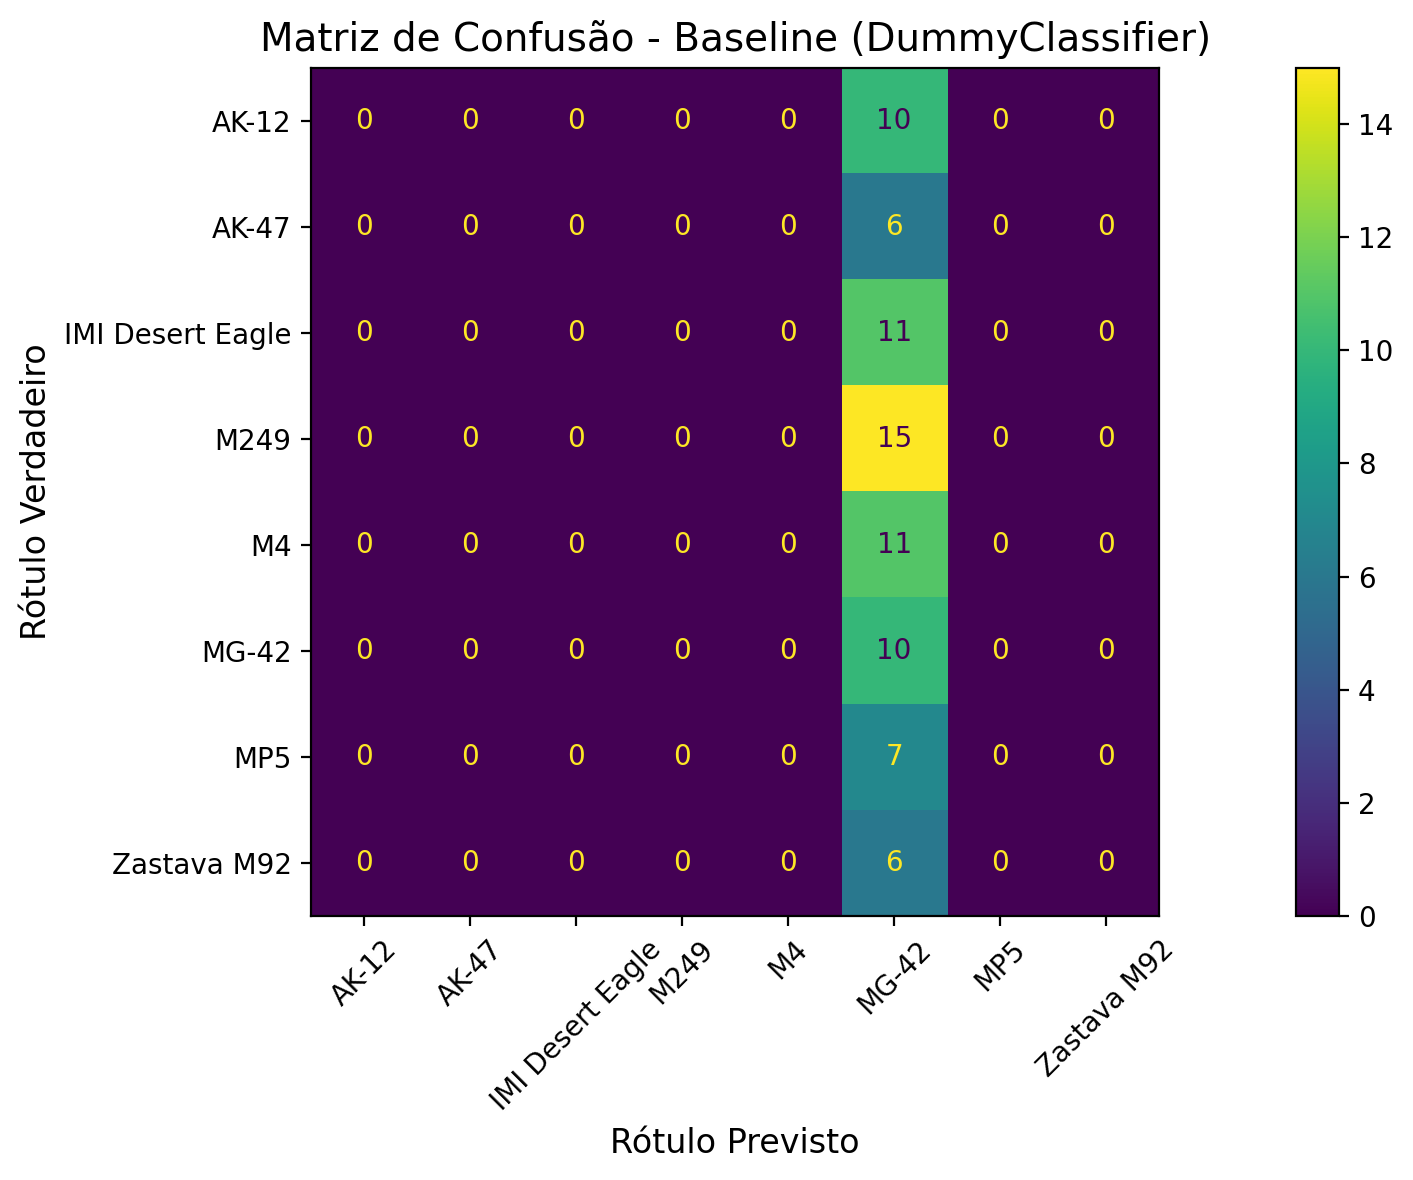

In [31]:
classes_armas = label_encoder.classes_
cm_baseline = confusion_matrix(y_teste, y_prev_baseline, labels=classes_armas)

fig, ax = plt.subplots(1, 1, figsize=(14, 6), dpi=200)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=classes_armas)
disp_baseline.plot(ax=ax, cmap="viridis", xticks_rotation=45)
ax.set_title("Matriz de Confusão - Baseline (DummyClassifier)", fontsize=14)
ax.set_xlabel("Rótulo Previsto", fontsize=12)
ax.set_ylabel("Rótulo Verdadeiro", fontsize=12)

plt.tight_layout()
plt.show()

### **Avaliando a MLP:**

Como a instância do MLP não faz também o processo de normalização e aplicação do PCA, é necessário criar um pipeline para o cunjunto de teste, imitando o que foi feito na ``funcao_objetivo_mlp()``, usando os melhores parâmetros encontrados pelo Optuna. 

Assim, no código abixo, é feito o pipeline aplicando a normalização e o pca, e criando o ``DataModule()`` para o conjunto de teste.

In [32]:
melh_params_mlp = melhor_trial_mlp.params

passos_pipeline_mlp = []
if melh_params_mlp["normalizar"]:

    dict_normalizadores = {
        "Standard": StandardScaler(),
        "MinMax": MinMaxScaler(),
        "MaxAbs": MaxAbsScaler()
    }
    
    tipo_norm_mlp = melh_params_mlp["tipo_norm"]
    passos_pipeline_mlp.append(dict_normalizadores[tipo_norm_mlp])

n_componentes_mlp = melh_params_mlp["pca_componentes"]
pca_mlp = PCA(n_components=n_componentes_mlp, random_state=SEED)
passos_pipeline_mlp.append(pca_mlp)

pipeline_mlp = make_pipeline(*passos_pipeline_mlp)

X_treino_processado = pipeline_mlp.fit_transform(X_treino)
X_val_processado = pipeline_mlp.transform(X_val)
X_teste_processado = pipeline_mlp.transform(X_teste)

X_treino_tensor_proc = torch.tensor(X_treino_processado, dtype=torch.float32)
y_treino_tensor = torch.tensor(y_treino_norm, dtype=torch.long)

X_val_tensor_proc = torch.tensor(X_val_processado, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_norm, dtype=torch.long)

X_teste_tensor_proc = torch.tensor(X_teste_processado, dtype=torch.float32)
y_teste_tensor = torch.tensor(y_teste_norm, dtype=torch.long)

dataset_treino = TensorDataset(X_treino_tensor_proc, y_treino_tensor)
dataset_val = TensorDataset(X_val_tensor_proc, y_val_tensor)
dataset_teste = TensorDataset(X_teste_tensor_proc, y_teste_tensor)

dm = DataModule(
    dataset_treino=dataset_treino,
    dataset_val=dataset_val,
    dataset_teste=dataset_teste
)

Criando e treinando o modelo com os parâmetros do melhor trial.

In [33]:
num_dados_entrada = X_treino_processado.shape[1]
modelo_mlp = cria_instancia_mlp(melhor_trial_mlp, num_dados_entrada, len(np.unique(y_treino)))

parada_antecipada_callback = EarlyStopping(
        monitor="val_loss",
        min_delta=0.005,
        patience=20,
        verbose=False,
        mode="min"
    )

NUM_EPOCAS = 400
treinador = L.Trainer(
    max_epochs=NUM_EPOCAS,
    callbacks=[parada_antecipada_callback],
    enable_progress_bar=False,
    logger=True,
    enable_model_summary=False
)

treinador.fit(modelo_mlp, dm)

C:\Users\arthur25004\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'funcao_ativacao' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['funcao_ativacao'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\arthur25004\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as 

Agora, para avaliar o modelo treinado, primeiro o modelo é colocado no modo de avaliação (``modelo_mlp.eval()``), de forma que o modelo se comporte de forma consistente durante a avaliação. 

Em seguida, os dados de teste são passados pelo modelo para obter as previsões, isso dentro do ``torch.no_grad()`` para desativar o cálculo de gradientes, e a métrica de f1-macro é calculada. Além disso, como o treino do modelo envolve vários processos estocásticos, como a iniciaização dos pesos, a ordem de embaralhamento dos dados, pode-se obter resultados levemente diferentes a cada execução, mesmo utilizando os mesmos hiperparâmetros.

**OBS:** Para o cálculo da f1-macro pode-se ou não converter as previsões para os rótulos.

In [34]:
modelo_mlp.eval()
dm.setup("test")

with torch.no_grad():
    saidas_teste = modelo_mlp(X_teste_tensor_proc)
    y_prev_mlp_tensor = torch.argmax(saidas_teste, dim=1)

y_prev_mpl = y_prev_mlp_tensor.numpy()
y_prev_mpl = label_encoder.inverse_transform(y_prev_mpl)

f1_macro_mlp = f1_score(y_teste, y_prev_mpl, average="macro")
print(f"O f1-macro do modelo de MLP foi: {f1_macro_mlp}")

O f1-macro do modelo de MLP foi: 0.7365965179175118


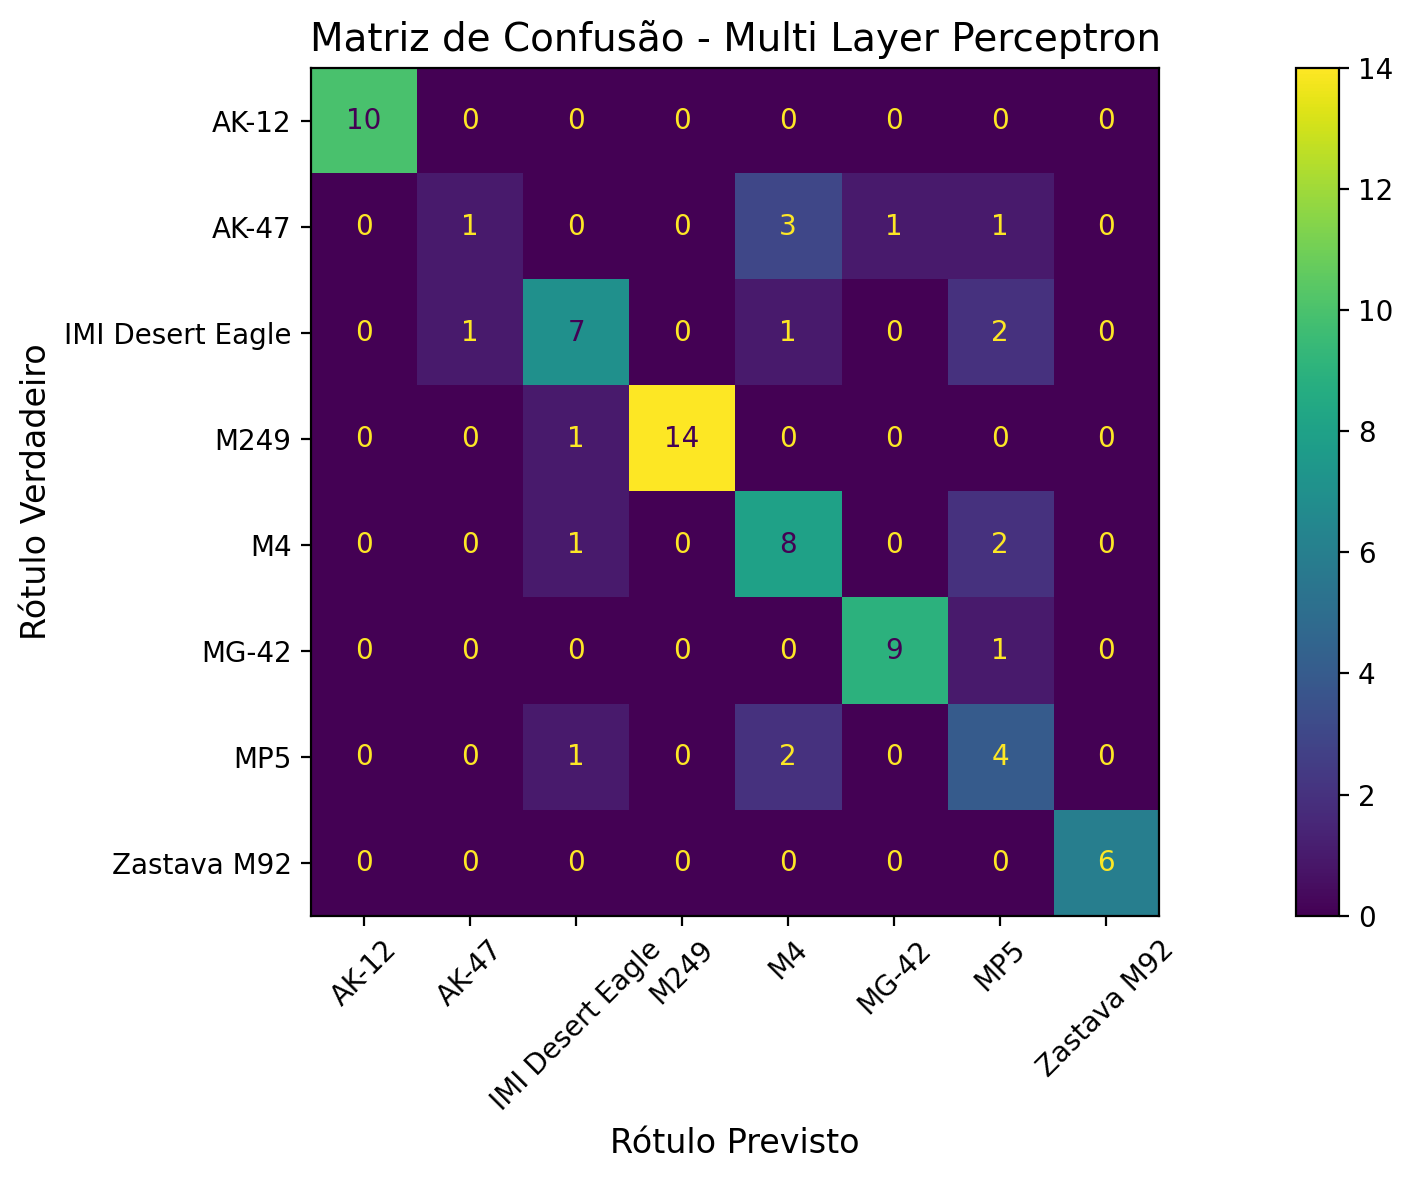

In [35]:
classes_armas = label_encoder.classes_
cm_mlp = confusion_matrix(y_teste, y_prev_mpl, labels=classes_armas)

fig, ax = plt.subplots(1, 1, figsize=(14, 6), dpi=200)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=classes_armas)
disp_mlp.plot(ax=ax, cmap="viridis", xticks_rotation=45)
ax.set_title("Matriz de Confusão - Multi Layer Perceptron", fontsize=14)
ax.set_xlabel("Rótulo Previsto", fontsize=12)
ax.set_ylabel("Rótulo Verdadeiro", fontsize=12)

plt.tight_layout()
plt.show()


#### **Curva de aprendizado**

Na curva de aprendizado abaixo, é possivel observar o comportamento do modelo ao longo das épocas de treinamento, tanto para a perda (``CrossEntropy``) no conjunto de treino quanto para o conjunto de validação. 

Nela é possível perceber que a perda inicialmente diminui, mas a partir de uma certa época, ambas as perta atingem um platô. Para que o modelo não continue aprendendo os padrões dos dados de treino, o que levaria a um overfitting, o *early stopping* interrompe o processo de treinamento, visto que a perda não melhorou (em relação a um certo limiar) na validação por 20 épocas consecutivas. 

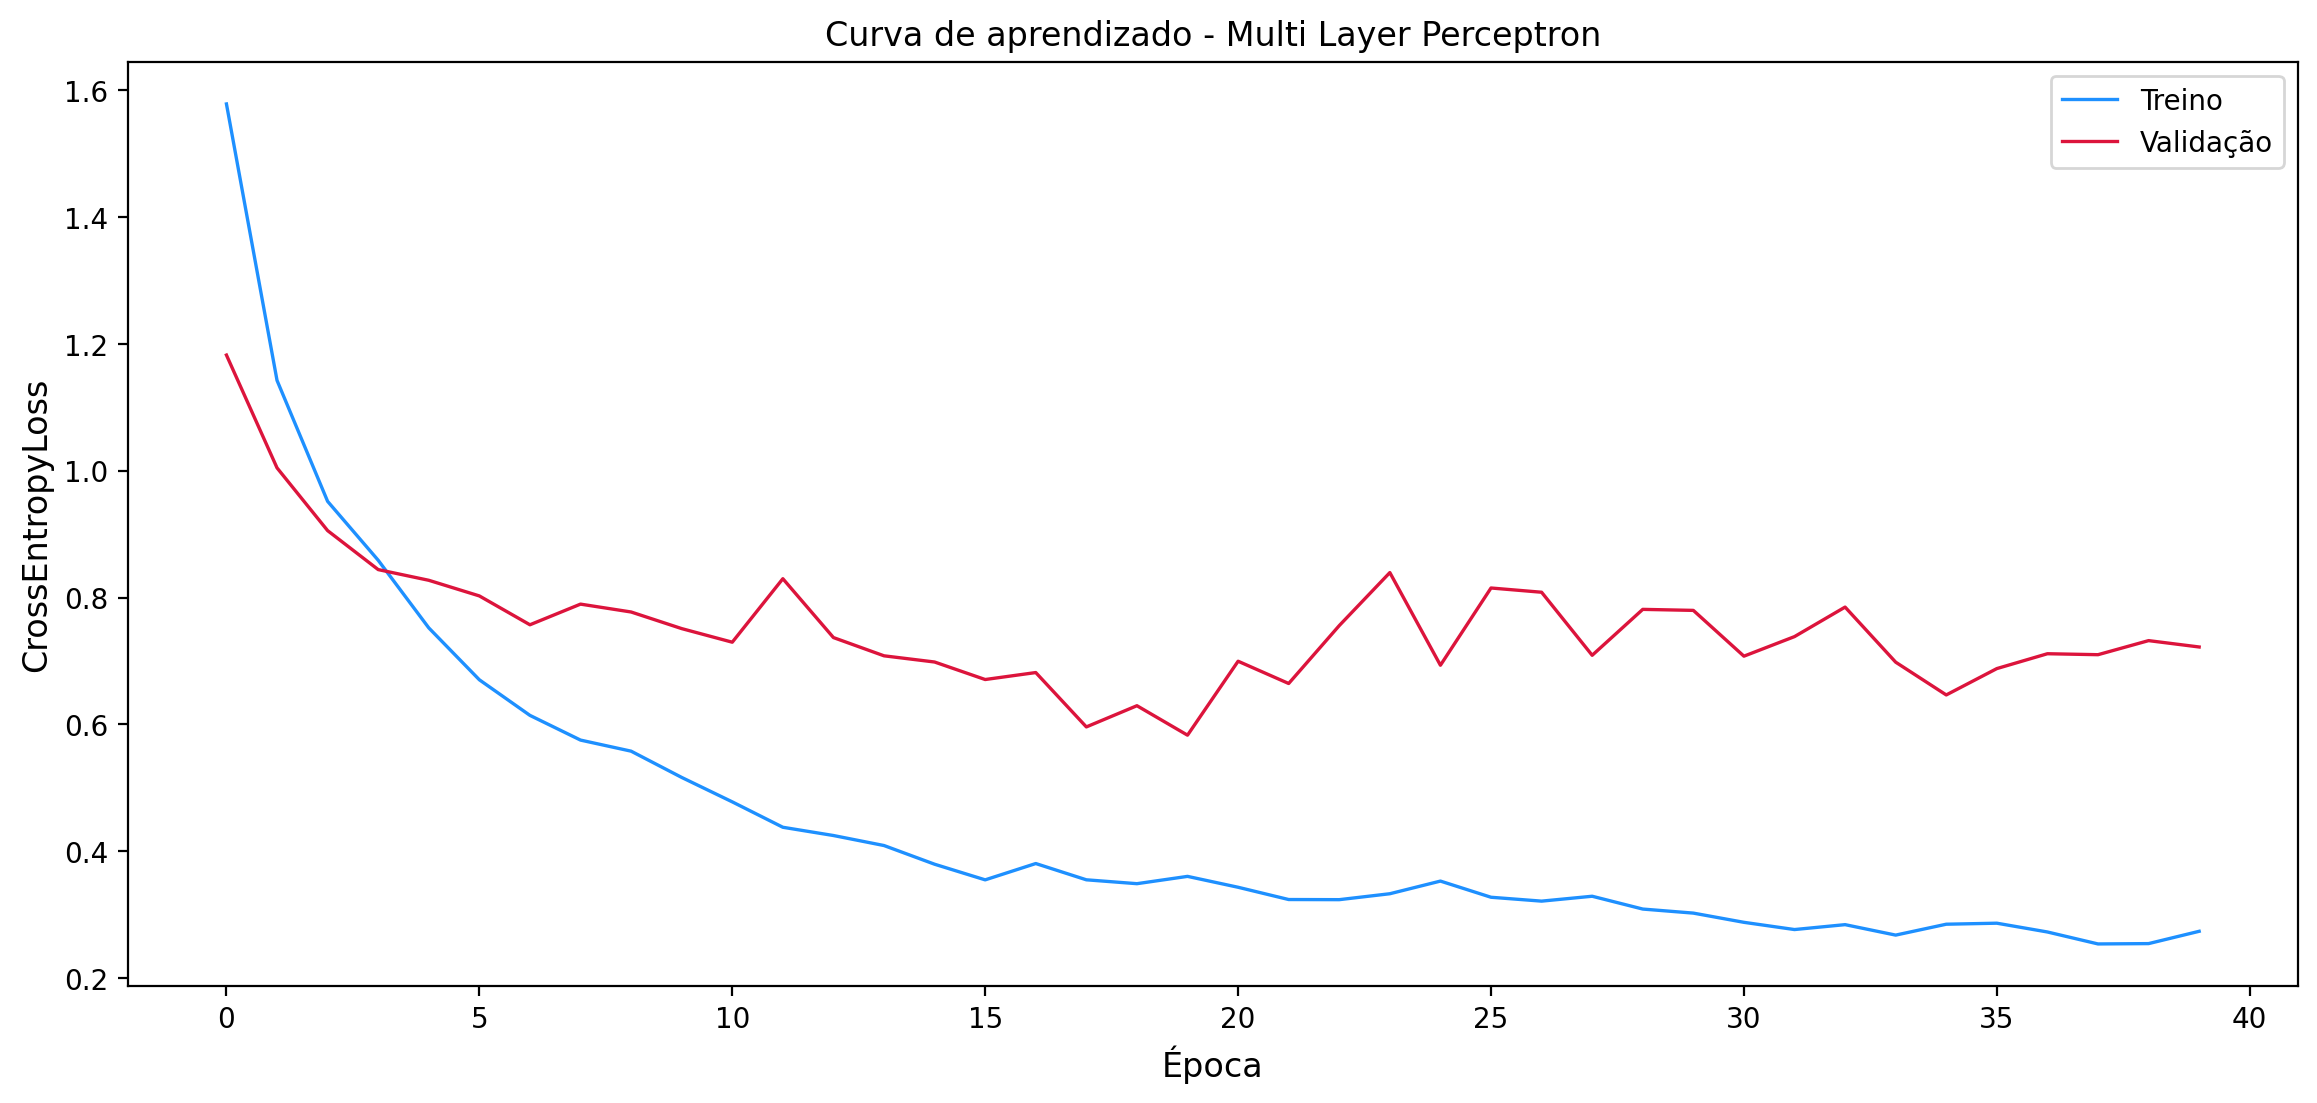

In [36]:
metricas_mlp = pd.read_csv(f"{treinador.logger.log_dir}/metrics.csv")
ca_treino = metricas_mlp["loss"].dropna().values
ca_val = metricas_mlp["val_loss"].dropna().values
epocas_duplicado = metricas_mlp["epoch"].dropna().values

epocas = range(0, int(len(epocas_duplicado)/2))

fig, ax = plt.subplots(1, 1, figsize=(14, 6), dpi=200)
ax.plot(epocas, ca_treino, linewidth=1.2, color="dodgerblue", label="Treino")
ax.plot(epocas, ca_val, linewidth=1.2, color="crimson", label="Validação")
ax.set_ylabel("CrossEntropyLoss", fontsize=12)
ax.set_xlabel("Época", fontsize=12)
ax.set_title("Curva de aprendizado - Multi Layer Perceptron")

plt.legend()
plt.show()

### **Avaliando a Floresta Aleatória:**

In [37]:
modelo_rf = cria_instancia_rf(melhor_trial_rf)
modelo_rf.fit(X_treino, y_treino_norm)

y_prev_rf = modelo_rf.predict(X_teste)
y_prev_rf = label_encoder.inverse_transform(y_prev_rf)
f1_macro_rf = f1_score(y_teste, y_prev_rf, average="macro")

print(f"O f1-macro do modelo de Floresta Aleatória foi: {f1_macro_rf}")


O f1-macro do modelo de Floresta Aleatória foi: 0.5114964885475721


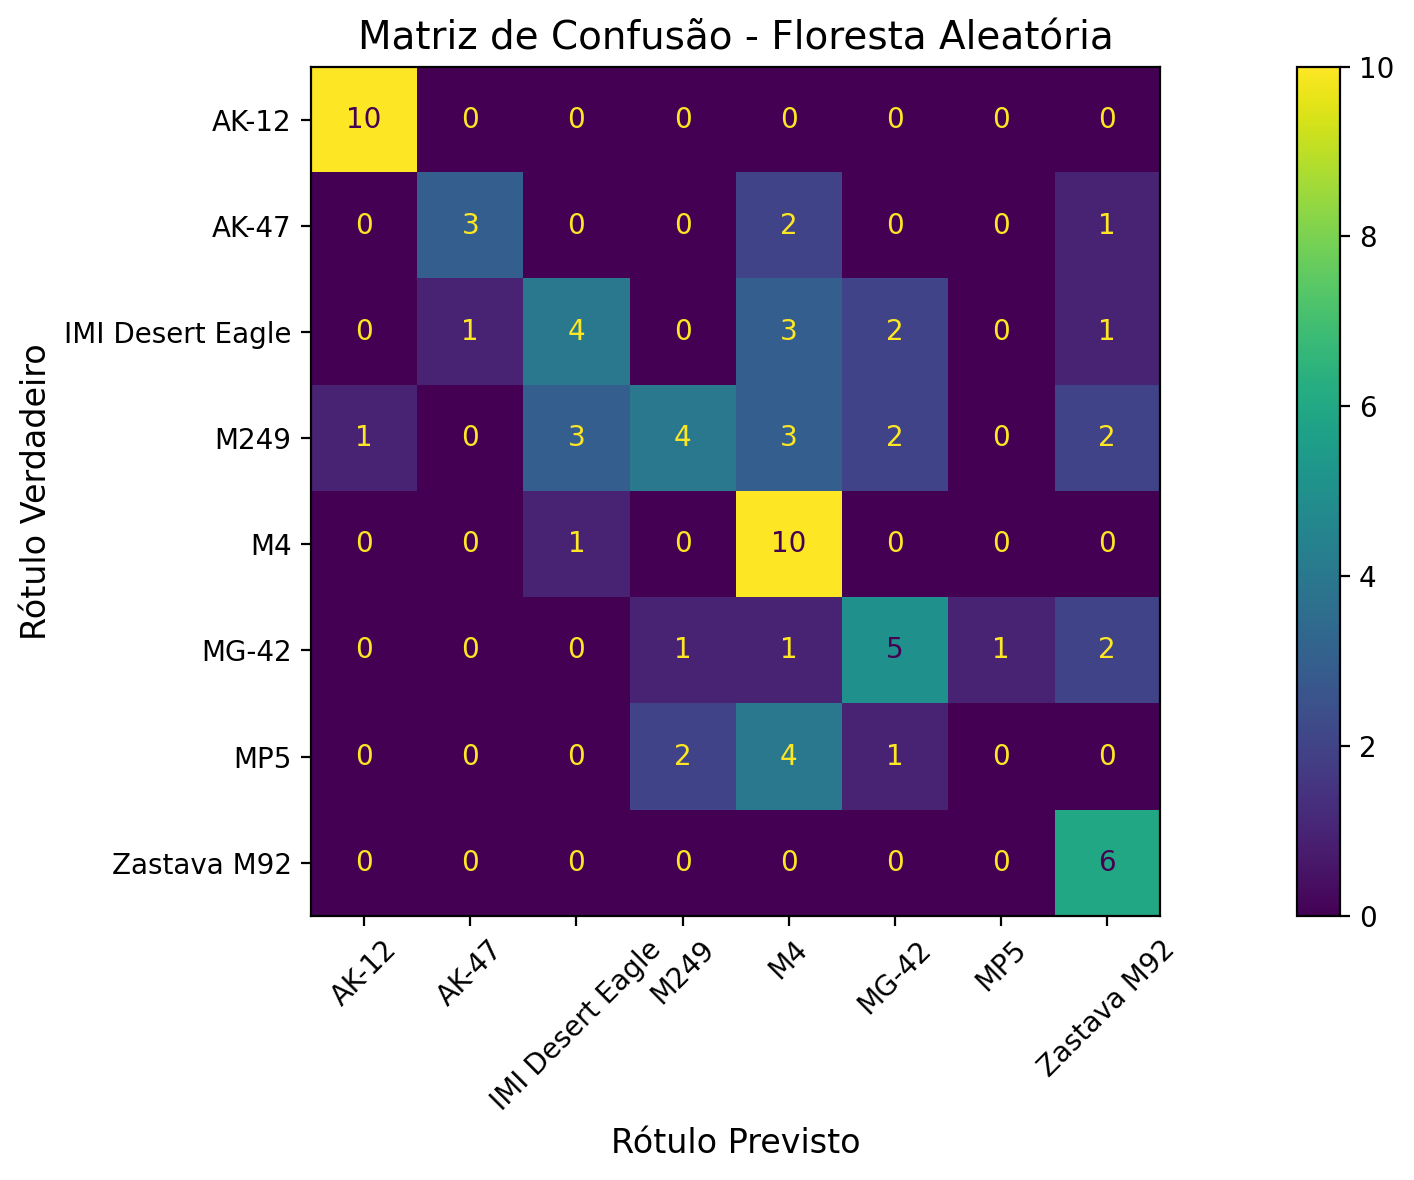

In [38]:
classes_armas = label_encoder.classes_
cm_rf = confusion_matrix(y_teste, y_prev_rf, labels=classes_armas)

fig, ax = plt.subplots(1, 1, figsize=(14, 6), dpi=200)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=classes_armas)
disp_rf.plot(ax=ax, cmap="viridis", xticks_rotation=45)
ax.set_title("Matriz de Confusão - Floresta Aleatória", fontsize=14)
ax.set_xlabel("Rótulo Previsto", fontsize=12)
ax.set_ylabel("Rótulo Verdadeiro", fontsize=12)

plt.tight_layout()
plt.show()

## **Conclusão**

Após a execução dos experimentos e a otimização de hiperparâmetros com o Optuna, os seguintes desempenhos foram alcançados na etapa de validação:

| Modelo | Estimativa F1-Macro (Validação) | F1-Macro (Teste) | Melhor Trial |
| :--- | :---: | :---: | :---: |
| Baseline (Dummy) | 0.0071 | 0.0290 | - |
| Floresta Aleatória | 0.9321 | 0.9460 | 1729 |
| MLP | 0.9603 | 0.9040 | 1702 |

Embora a rede neural MLP tenha apresentado a melhor estimativa durante a validação (0.9603), a Floresta Aleatória (Random Forest) revelou-se o modelo mais robusto ao lidar com os dados de teste, alcançando um F1-Macro final de **0.9460**. 

A superioridade da Floresta Aleatória nos dados de teste pode ser atribuída a alguns fatores como: **melhor generalização**, visto que a MLP pode ter capturado padrões específicos do conjunto de validação, enquanto a Floresta Aleatória, por ser um modelo de ensemble (que usa a técnica de *bagging*), tende a ser mais resistente a variações e ruídos nos dados.

---

Dessa maneira, o notebook demonstrou a viabilidade técnica da identificação do tipo de arma utilizada através do som. A transição de um modelo baseline, para modelos que superam os 90% de *f1-macro*, mostra a capacidade das características do som extraídas e da técnica de otimização adotada.

## **Apêndice**

### **A matemática por trás do ``Adam``** [10]

1. **Inicialização:**: é inicializando dois vetores de momento, um para a média do gradiente (primeiro momento - $m$), e outro para a média do quadrado do gradiente (segundo momento - $v$), cada um com o mesmo tamanho do número de parâmetros do modelo.
- $m_0 = 0$
- $v_0 = 0$
- $t = 0$
2. **Cálculo do Gradiente:**
A cada iteração (época) é calculado o gradiente $g_t$, que é a derivada da função de perda (que estamos tentando minimizar), com relação ao parâmetro $\theta _t$ que está sendo atualizado. $$g_t  = \nabla _{\theta} f_t (\theta _{t-1})$$
Em que: 
- $g_t$: gradiente na iteração $t$.
- $\nabla _{\theta}$: o gradiente para o parâmetro $\theta$.
- $f_t (\theta _{t-1})$: a função de perda aplicada aos valores dos parâmetros da iteração anterior.  

3. **Atulização do Primeiro Momento (m):** O primeiro momento é atualizado usando uma média móvel do gradiente. A atualização é a combinação do valor anterior de $m$ e o novo gradiente $g_t$, controlada pelos parâmetros $\beta _1$ e $1 - \beta _1$. Esse processo pode ser visto como uma forma de dar mais peso aos gradientes mais recentes, enquanto ainda mantém uma média dos gradientes anteriores (uma estimativa suave da direção do gradiente). $$m_t = \beta _1 m_{t-1} + (1 - \beta _1) g_t$$ Em que:
- $m_t$: é o vetor do primeiro momento na iteração $t$.
- $\beta _1$: parâmetro de decaimento exponencial para o primeiro momento.
- $m_{t-1}$: é o vetor do primeiro momento na iteração anterior.
- $g_t$: é o vetor do gradiente na iteração $t$.

4. **Atualização do Segundo Momento (v):** O segundo momento é atualizado usando uma média móvel do quadrado do gradiente, como uma variância (imprevisibilidade) dos gradientes. A atualização é a combinação do valor anterior de $v$ e o novo gradiente $g_t$, controlada pelos parâmetros $\beta _2$ e $1 - \beta _2$. $$v_t = \beta _2 v_{t-1} + (1 - \beta _2) g_t^2$$
Em que: 
- $v_t$: é o vetor do segundo momento na iteração $t$.
- $\beta _2$: parâmetro de decaimento exponencial para o segundo momento.
- $v_{t-1}$: é o vetor do segundo momento na iteração anterior.
- $g_t^2$: é o vetor do quadrado do gradiente na iteração $t$.

5. **Correção de Viés:** Devido à inicialização dos momentos com zero, os primeiros momentos tendem a ser subestimados, especialmente nas primeiras iterações. Para corrigir esse viés, são aplicadas as seguintes correções: $$\hat{m}_t = \frac{m_t}{1 - \beta _1^t}$$ $$\hat{v}_t = \frac{v_t}{1 - \beta _2^t}$$ Em que:
- $\hat{m}_t$: é o vetor do primeiro momento corrigido na iteração $t$.
- $\hat{v}_t$: é o vetor do segundo momento corrigido na iteração $t$.
- $\beta _1^t$: é o parâmetro de decaimento exponencial para o primeiro momento na iteração $t$.
- $\beta _2^t$: é o parâmetro de decaimento exponencial para o segundo momento na iteração $t$.

6. **Atualização dos Parâmetros:** Finalmente, os parâmetros do modelo são atualizados usando os momentos corrigidos e a taxa de aprendizado $\alpha$: $$\theta _{t+1} = \theta _{t} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$ Em que:
- $\theta _{t+1}$: é o vetor de parâmetros atualizado para a próxima iteração.
- $\theta _{t}$: é o vetor de parâmetros na iteração atual.
- $\alpha$: é a taxa de aprendizado, que controla o tamanho do passo de atualização.
- $\hat{m}_t$: é o vetor do primeiro momento corrigido na iteração $t$.
- $\hat{v}_t$: é o vetor do segundo momento corrigido na iteração $t$.
- $\epsilon$: é um pequeno valor adicionado para evitar divisão por zero.

## **Refrências**

[1] AYDEMR, Emrah. Gunshot Audio Dataset. [S. l.]: Kaggle, 2023. Disponível em: https://www.kaggle.com/datasets/emrahaydemr/gunshot-audio-dataset/data. Acesso em: 5 abr. 2026.

[2] MEL-FREQUENCY cepstrum. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Mel-frequency_cepstrum. Acesso em: 5 abr. 2026.

[3] MEL scale. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Mel_scale. Acesso em: 5 abr. 2026.

[4] SPECTRAL centroid. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Spectral_centroid. Acesso em: 5 abr. 2026.

[5] LIBROSA. librosa.feature.spectral_contrast. [S. l.], 2024. Disponível em: https://librosa.org/doc/main/generated/librosa.feature.spectral_contrast.html. Acesso em: 5 abr. 2026.

[6] ZERO-crossing rate. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Zero-crossing_rate. Acesso em: 5 abr. 2026.

[7] CHROMA feature. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Chroma_feature. Acesso em: 5 abr. 2026.

[8] MULTILAYER perceptron. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Multilayer_perceptron. Acesso em: 5 abr. 2026.

[9] PYTORCH. CrossEntropyLoss. [S. l.], 2024. Disponível em: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html. Acesso em: 5 abr. 2026.

[10] PRADHAN, R. The Math Behind Adam Optimizer. Towards Data Science, 2018. Disponível em: https://towardsdatascience.com/the-math-behind-adam-optimizer-c41407efe59b/. Acesso em: 5 abr. 2026.

[11] HUGHES, Chris P. A brief overview of Cross Entropy Loss. Medium, 2023. Disponível em: https://medium.com/@chris.p.hughes10/a-brief-overview-of-cross-entropy-loss-523aa56b75d5. Acesso em: 5 abr. 2026.

[12] PYTORCH. CrossEntropyLoss. [S. l.], 2024. Disponível em: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html. Acesso em: 5 abr. 2026.

[13] CASSAR, Daniel Roberto. Multilayer Perceptron em Python puro. [Jupyter Notebook], Ilum – Escola de Ciência, Campinas, 2026.

[14] CASSAR, Daniel Roberto. Construindo e treinando redes neurais com PyTorch e Lightning. [Jupyter Notebook], Ilum – Escola de Ciência, Campinas, 2026.
k.

[15] PRINCIPAL component analysis. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Principal_component_analysis. Acesso em: 5 abr. 2026.

[16] Tuncer, T., Dogan, S., Akbal, E., Aydemir, E. (2021). An Automated Gunshot Audio Classification Method Based On Finger Pattern Feature Generator And Iterative Relieff Feature Selector, Journal of Engineering Science of Adıyaman University